# Demo: Simple Linear Regression_Week 11-2_20251113

In this notebook we will:

1. Generate a <u>*population*</u> with one independent variable (X) and one dependent variable (Y).
2. Draw a <u>*random sample*</u> from this population.
3. Run simple linear regression (**OLS**) on the sample.
4. Briefly interpret the output.

We will use the following packages/modules:
- `numpy` for random data generation
- `pandas` for data handling
- `matplotlib` for visualization
- `statsmodels` for OLS regression

## Import Libraries

In [1]:
# If statsmodels is not installed in your environment, run:
# %pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## 1. Generate a population

We first create a population dataset.

Model: Y = $\beta_0$ + $\beta_1$ X + $\varepsilon$

- Set a <u>*random seed*</u> so the results are reproducible.
- Generate X from a normal distribution using `np.random.normal()`.
- Generate the error term $\varepsilon$ from a normal distribution.
- Compute Y using the linear model.

We will create a population of 100,000 observations.


In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Population size
N = 100000

# True parameters
beta_0 = 2.0   # intercept
beta_1 = 3.5   # slope
sigma = 1.0    # standard deviation of the error term

# Generate independent variable X from N(0, 1)
X_pop = np.random.normal(loc=0, scale=1, size=N)

# Generate error term epsilon from N(0, sigma^2)
epsilon_pop = np.random.normal(loc=0, scale=sigma, size=N)

# Generate dependent variable Y from the model
Y_pop = beta_0 + beta_1 * X_pop + epsilon_pop

# Put into a DataFrame (useful later)
pop = pd.DataFrame({"X": X_pop,"Y": Y_pop})

pop.head()

,X,Y
0,0.496714,4.769094
1,-0.138264,0.360720
2,0.647689,4.842347
3,1.523030,6.711366
4,-0.234153,0.853060


## 2. Draw a random sample from the population

In practice, we do not observe the whole population. Instead, we have a <u>*random sample*</u>.

Here we simulate simple random sampling in Python:

- Choose a sample size `n`.
- Use the `.sample()` method in pandas.
- Set `random_state` so that the sample is reproducible.


In [4]:
# Sample size
n = 100

# Draw a random sample (simple random sampling without replacement)
sample = pop.sample(n=n, random_state=1)

sample.head()

,X,Y
43660,1.106110,5.375784
87278,1.237998,7.300341
14317,0.585813,4.425618
81932,1.964753,7.316975
95321,1.262673,7.790468


## 3. Visualize the sample

We can create a scatter plot of **Y vs. X** in the sample to see the linear relationship.

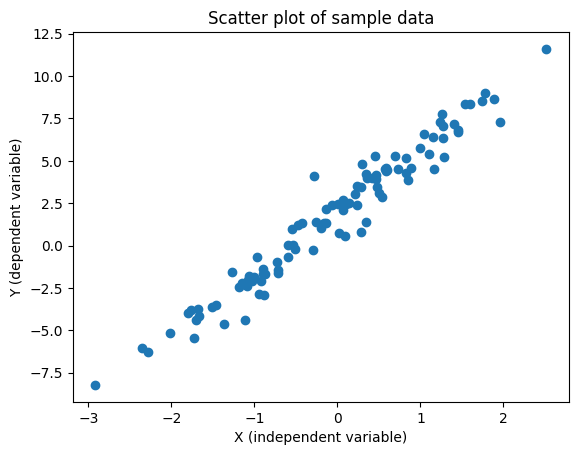

In [5]:
plt.figure()
plt.scatter(sample["X"], sample["Y"])
plt.xlabel("X (independent variable)")
plt.ylabel("Y (dependent variable)")
plt.title("Scatter plot of sample data")
plt.show()

## 4. Run simple linear regression (OLS)

We now estimate the model:

$\hat{y}$ = $\hat{\beta_0}$ + $\hat{\beta_1}$ x

Steps in `statsmodels`:

1. Define the dependent variable `y`.
2. Define the independent variable `x`.
3. Add a constant term (intercept) using `sm.add_constant()`.
4. Use `sm.OLS(y, x).fit()` to estimate the model.
5. Look at the summary output.

In [6]:
# 1. Dependent variable
y = sample["Y"]

# 2. Independent variable(s)
x = sample[["X"]]  

# 3. Add constant (intercept term)
x = sm.add_constant(x)  # adds a column of ones named 'const'

# 4. Fit the OLS model
model = sm.OLS(y, x)
results = model.fit()

# 5. Show summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2046.
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.79e-67
Time:                        18:26:41   Log-Likelihood:                -129.13
No. Observations:                 100   AIC:                             262.3
Df Residuals:                      98   BIC:                             267.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9336      0.089     21.723      0.000       1.757       2.110
X              3.6590      0.081     45.234      0.000       3.498       3.820
==============================================================================
Omnibus:                        5.141   Durbin-Watson:                   1.763
Prob(Omnibus):                  0.076   Jarque-Bera (JB):                7.116
Skew:                          -0.103   Prob(JB):                       0.0285
Kurtosis:                       4.290   Cond. No.                         1.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 5. Interpreting the regression output

Key parts of the output:

- **coef** for `const` → estimated intercept $\hat{\beta}_0$
- **coef** for `X` → estimated slope $\hat{\beta}_1$
- **std err** → standard errors of the estimates
- **t** and **P>|t|** → t-statistics and p-values for hypothesis tests:
  - $H_0: \beta_j = 0$
- **R-squared** → proportion of variation in Y explained by X

Compare the estimated coefficients with the **true parameters**:
- $\beta_0 = 2.0$
- $\beta_1 = 3.5$

Because we used a **random sample**, the estimates will be close but not exactly equal to the true values.

## 6. Sampling distribution of the slope estimator $\hat{\beta}_1$

To understand that $\hat{\beta}_1$ is a **random variable**, we:

1. Repeatedly draw random samples (of size **n**) from the *same* population.
2. Run OLS each time.
3. Store the estimated slope $\hat{\beta}_1$ from each sample.
4. Plot the histogram of all the $\hat{\beta}_1$ estimates.

This approximates the **sampling distribution** of $\hat{\beta}_1$.

We expect:
- The distribution to be centered around the **true** $\beta_1 = 3.5$.
- The spread to shrink if we increase the sample size **n**.

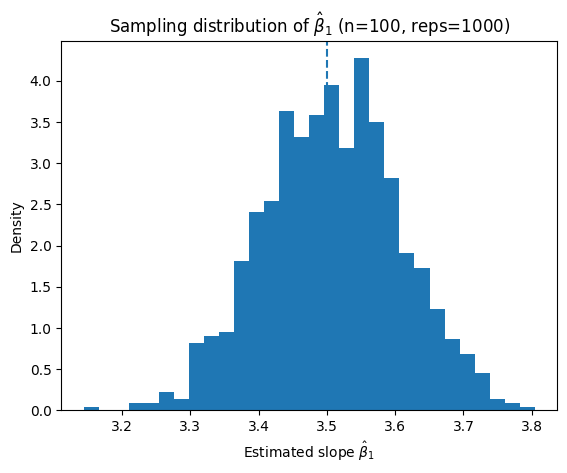

True beta_1: 3.5
Mean of hat(beta_1): 3.5072434929049865
Std of hat(beta_1): 0.0992812696673227


In [7]:
# Number of repetitions (how many samples we draw)
num_reps = 1000

# Sample size (same as before, but you can change it)
n = 100

beta1_hats = []

for r in range(num_reps):
    # Draw a random sample from the population
    sample_r = pop.sample(n=n, replace=False)  # simple random sampling

    # Define y and X
    y_r = sample_r["Y"]
    X_r = sample_r[["X"]]
    X_r = sm.add_constant(X_r)

    # Fit OLS
    model_r = sm.OLS(y_r, X_r)
    results_r = model_r.fit()

    # Store the estimated slope (coefficient on X)
    beta1_hats.append(results_r.params["X"])

beta1_hats = np.array(beta1_hats)

# Plot histogram of the slope estimates
plt.figure()
plt.hist(beta1_hats, bins=30, density=True)
plt.axvline(x=beta_1, linestyle="dashed")  # true beta1
plt.xlabel(r"Estimated slope $\hat{\beta}_1$")
plt.ylabel("Density")
plt.title(f"Sampling distribution of $\\hat{{\\beta}}_1$ (n={n}, reps={num_reps})")
plt.show()

# Show mean and std of the estimated slopes
print("True beta_1:", beta_1)
print("Mean of hat(beta_1):", beta1_hats.mean())
print("Std of hat(beta_1):", beta1_hats.std())